In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action= 'ignore', category=FutureWarning)




In [4]:
# Load dataset
df = pd.read_csv("/Users/jein/env/env/Fashion_product_intelligence/model/fashion_products.csv")

df.head()

,id,productDisplayName,brandName,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,filename,imageURL
0,57896,Femella Women Off White Shorts,Femella,Women,"{'id': 9, 'typeName': 'Apparel', 'active': Tru...","{'id': 29, 'typeName': 'Bottomwear', 'active':...","{'id': 72, 'typeName': 'Shorts', 'active': Tru...",Off White,Summer,2012.0,Casual,57896.jpg,http://assets.myntassets.com/v1/images/style/p...
1,37297,Casio Enticer Men Black Analogue Watches (A504...,CASIO,Men,"{'id': 1, 'typeName': 'Accessories', 'active':...","{'id': 27, 'typeName': 'Watches', 'active': Tr...","{'id': 66, 'typeName': 'Watches', 'active': Tr...",Black,Winter,2016.0,Casual,37297.jpg,http://assets.myntassets.com/v1/image/style/pr...
2,3721,Lee Men Black Canvas Belt,Lee,Men,"{'id': 1, 'typeName': 'Accessories', 'active':...","{'id': 13, 'typeName': 'Belts', 'active': True...","{'id': 49, 'typeName': 'Belts', 'active': True...",Black,Summer,2011.0,Casual,3721.jpg,http://assets.myntassets.com/v1/images/style/p...
3,51041,Enamor Women Ivory Coloured Briefs,Enamor,Women,"{'id': 9, 'typeName': 'Apparel', 'active': Tru...","{'id': 136, 'typeName': 'Innerwear', 'active':...","{'id': 137, 'typeName': 'Briefs', 'active': Tr...",White,Summer,2017.0,Casual,51041.jpg,http://assets.myntassets.com/v1/images/style/p...
4,2833,Lee Cooper Men's Casual Leather Darknight Blac...,Lee Cooper,Men,"{'id': 10, 'typeName': 'Footwear', 'active': T...","{'id': 33, 'typeName': 'Shoes', 'active': True...","{'id': 93, 'typeName': 'Casual Shoes', 'active...",Black,Summer,2012.0,Casual,2833.jpg,http://assets.myntassets.com/v1/images/style/p...


<!-- Understanding Data -->

In [5]:
df.shape


(44446, 13)

In [7]:
df.columns


Index(['id', 'productDisplayName', 'brandName', 'gender', 'masterCategory',
       'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage',
       'filename', 'imageURL'],
      dtype='object')

In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44446 entries, 0 to 44445
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44446 non-null  int64  
 1   productDisplayName  44439 non-null  object 
 2   brandName           44446 non-null  object 
 3   gender              44446 non-null  object 
 4   masterCategory      44446 non-null  object 
 5   subCategory         44446 non-null  object 
 6   articleType         44446 non-null  object 
 7   baseColour          44431 non-null  object 
 8   season              44425 non-null  object 
 9   year                44445 non-null  float64
 10  usage               44129 non-null  object 
 11  filename            44446 non-null  object 
 12  imageURL            44446 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 4.4+ MB


In [8]:
df.isnull().sum()


id                      0
productDisplayName      7
brandName               0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
filename                0
imageURL                0
dtype: int64

<!-- Handle Missing Values -->

In [5]:
# Fill missing TEXT values

df["productDisplayName"].fillna("Unknown", inplace=True)
df["season"].fillna("Unknown", inplace=True)
df["usage"].fillna("Unknown", inplace=True)
df["baseColour"].fillna("Unknown", inplace=True)
df["brandName"].fillna("Unknown", inplace=True)


In [6]:
# Fill missing YEAR values and convert into int
df["year"].fillna(df["year"].median(), inplace=True)
df["year"] = df["year"].astype(int)


In [7]:
df.isnull().sum()


id                    0
productDisplayName    0
brandName             0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
filename              0
imageURL              0
dtype: int64

<!-- Standardize Categories -->

In [8]:
text_cols = [
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "usage",
    "season",
    "brandName"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()


In [9]:
#  Remove duplicate products -->

df.drop_duplicates(subset="id", inplace=True)

In [10]:
# Remove products without image URL
df = df[df["imageURL"].notna()]


Insight - Images are mandatory for deep learning.

In [15]:
df.shape


(44446, 13)

In [11]:
# Save cleaned dataset
df.to_csv("fashion_products_clean.csv", index=False)


Cleaning is done.

EDA - understand business patterns.

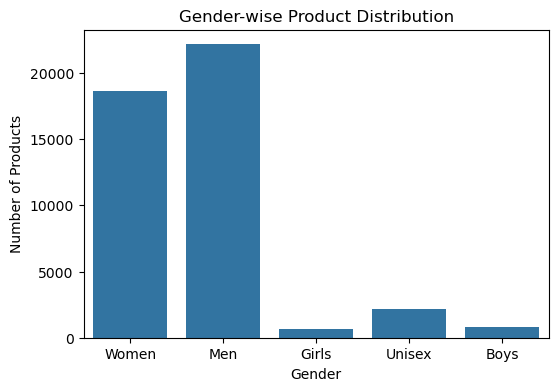

In [ ]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender-wise Product Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Products")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/gender_distribution.png") 
plt.show()



Insight - Tells men category dominates.

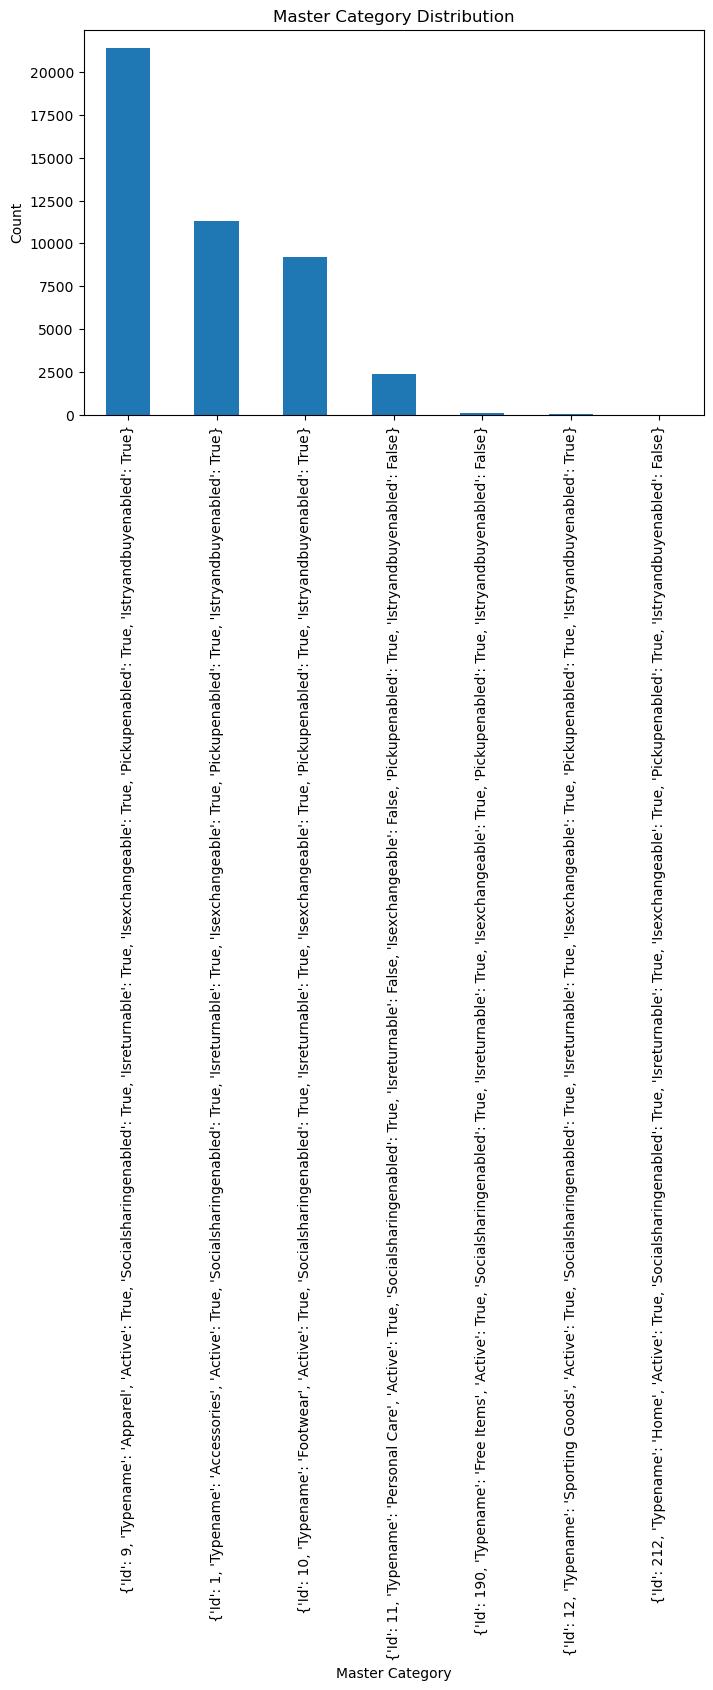

In [25]:
# Category Distribution
plt.figure(figsize=(8,5))
df["masterCategory"].value_counts().plot(kind="bar")
plt.title("Master Category Distribution")
plt.xlabel("Master Category")
plt.ylabel("Count")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/category_distribution.png")
plt.show()


Insight - Can find category dominates

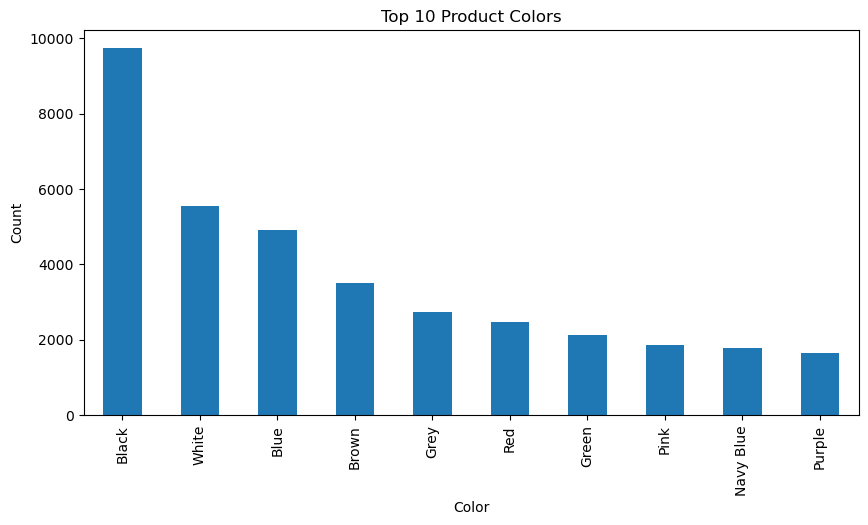

In [26]:
# Color Trends
plt.figure(figsize=(10,5))
df["baseColour"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Product Colors")
plt.xlabel("Color")
plt.ylabel("Count")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/color_trends.png")
plt.show()


insight - it showing black colour is popular

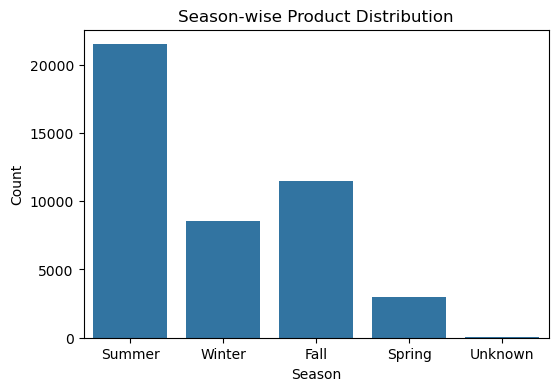

In [27]:
# Seasonal Trends
plt.figure(figsize=(6,4))
sns.countplot(x="season", data=df)
plt.title("Season-wise Product Distribution")
plt.xlabel("Season")
plt.ylabel("Count")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/seasonal_trends.png")
plt.show()


Insight - Can find season has more products

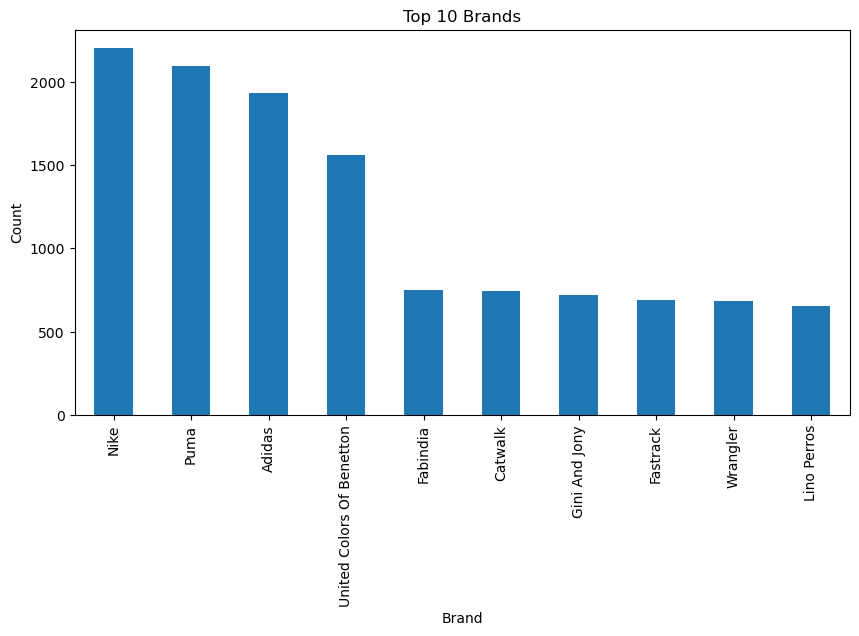

In [28]:
# Brand Distribution
plt.figure(figsize=(10,5))
df["brandName"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/brand_distribution.png")
plt.show()


Insight - Showing Nike brands is dominate

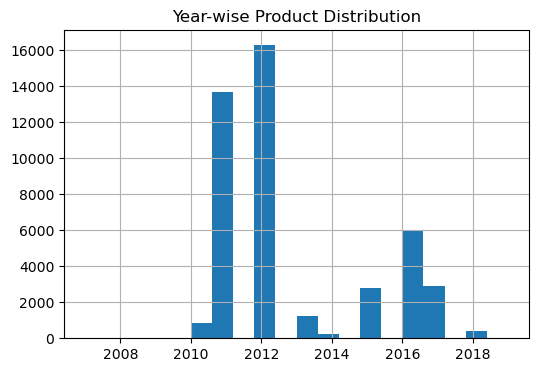

In [16]:
# Year Distribution
plt.figure(figsize=(6,4))
df["year"].dropna().astype(int).hist(bins=20)
plt.title("Year-wise Product Distribution")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/year_disribution.png")
plt.show()

Insight : Most product belongs to 2011 and 2012

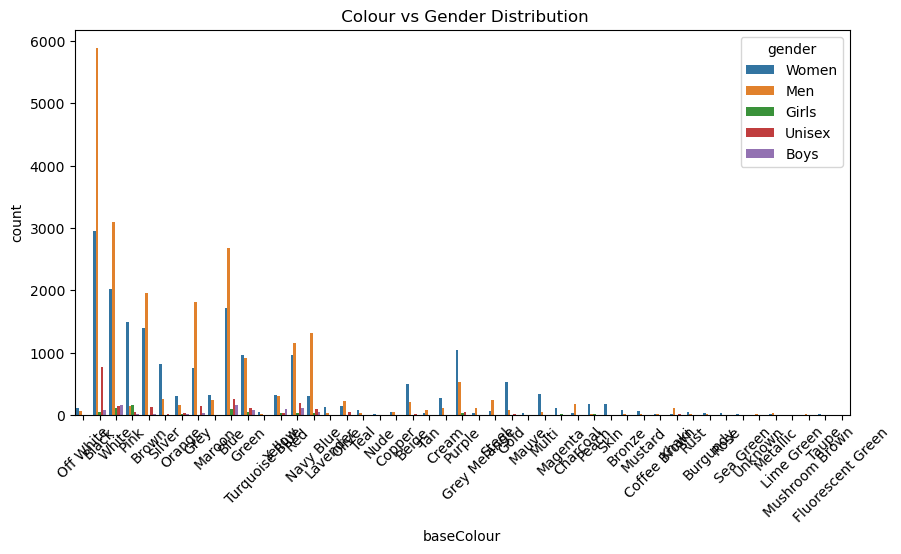

In [24]:
# Colour vs Gender distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="baseColour", hue="gender")
plt.xticks(rotation=45)
plt.title(" Colour vs Gender Distribution")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/Colour_vs_gender.png")
plt.show()

Insight : Bright and Light Colours are higher usage

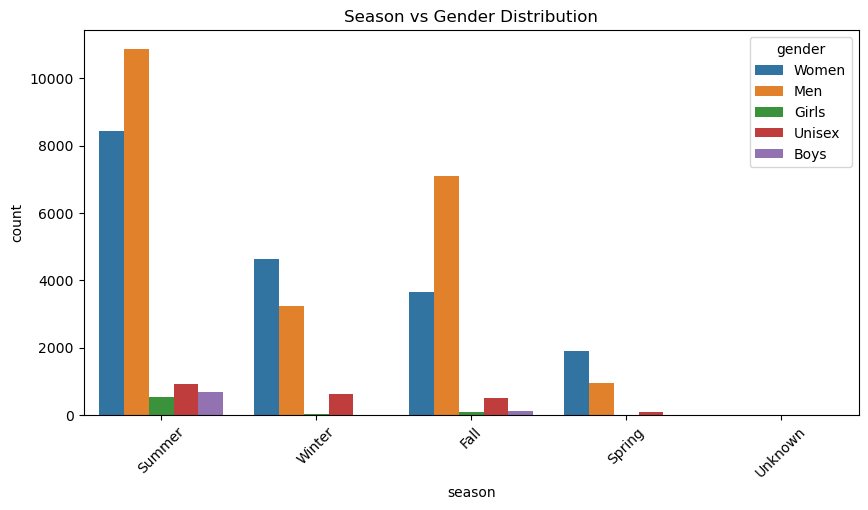

In [25]:
# season

# Season vs Gender distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="season", hue="gender")
plt.xticks(rotation=45)
plt.title("Season vs Gender Distribution")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/season_vs_gender.png")
plt.show()

Insight : Summer season probabably have high buyers

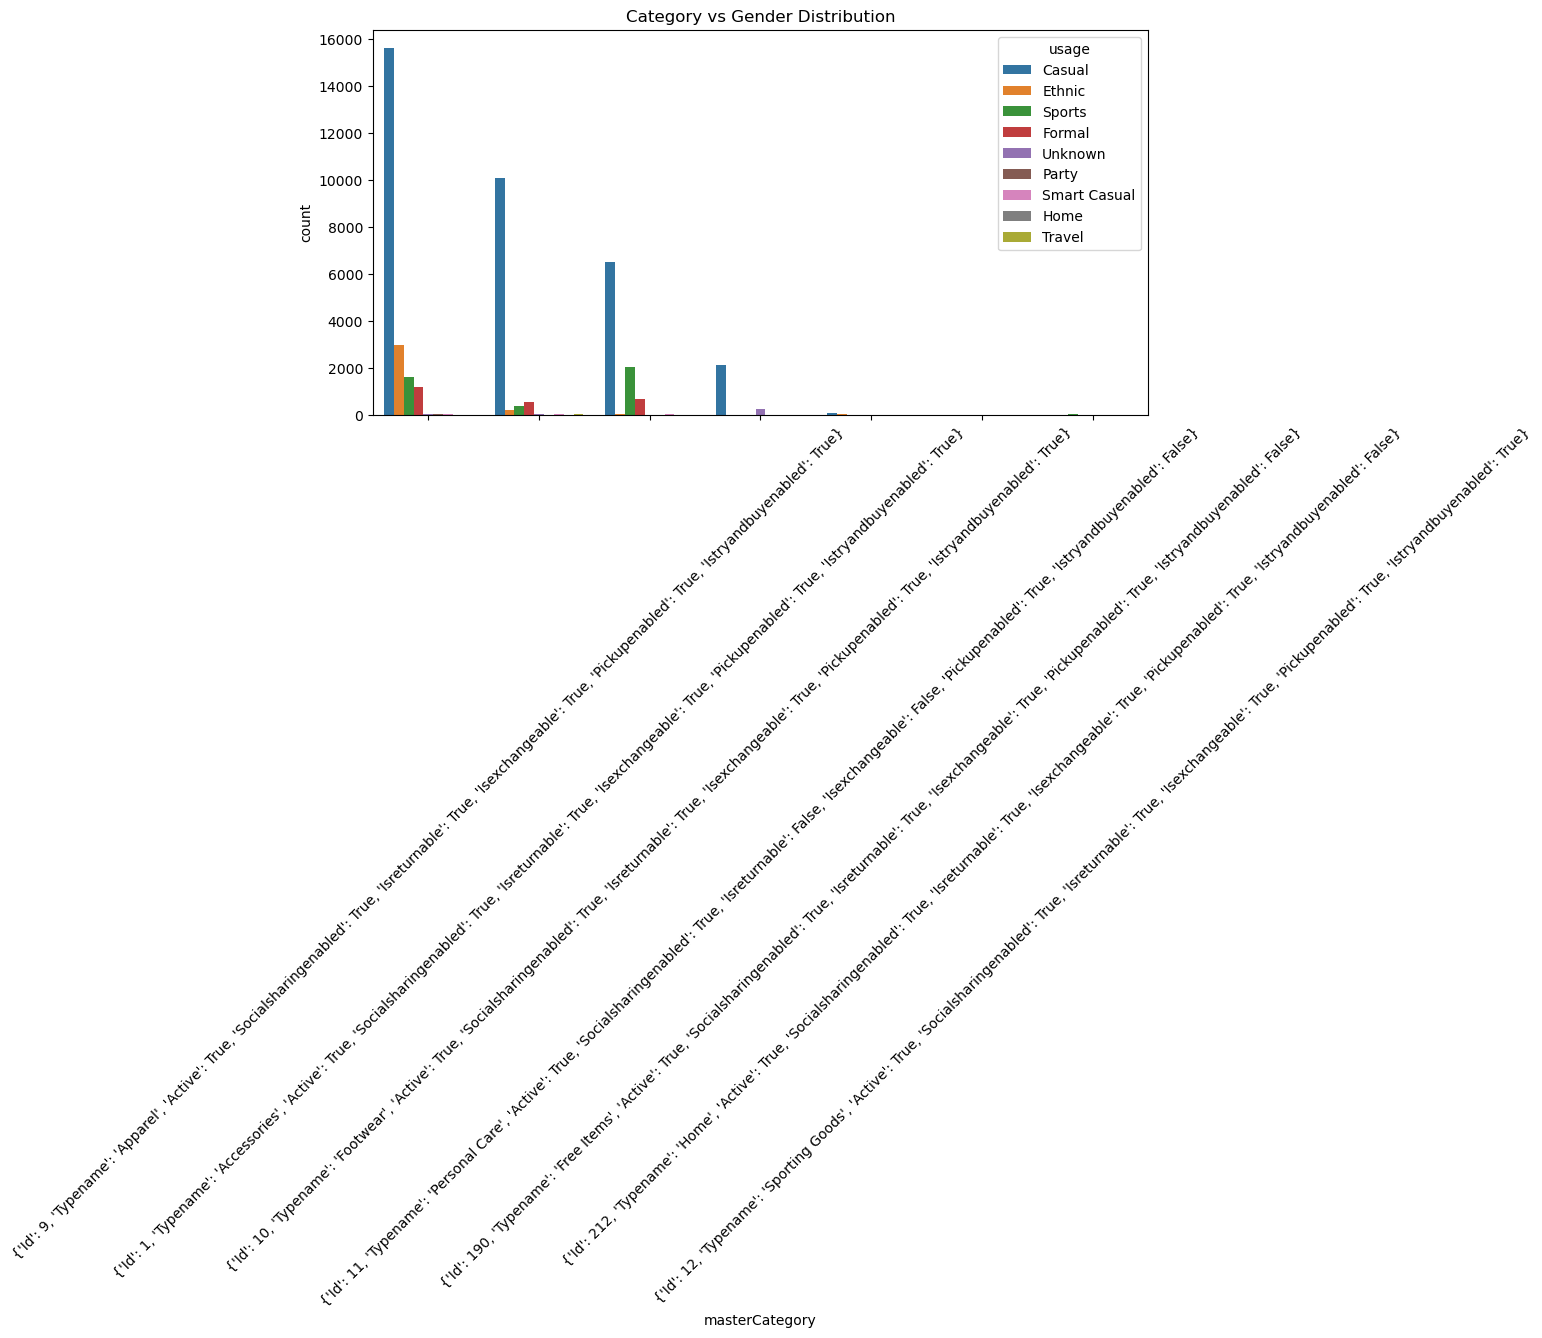

In [27]:
# Category vs Gender Distribution"
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="masterCategory", hue="usage")
plt.xticks(rotation=45)
plt.title("Category vs Gender Distribution")
plt.savefig("/Users/jein/env/env/Fashion_product_intelligence/eda_charts/Colour_vs_gender.png")
plt.show()

Insight :Casual products are highly in use.
 Casual products are highly used by mens during summer

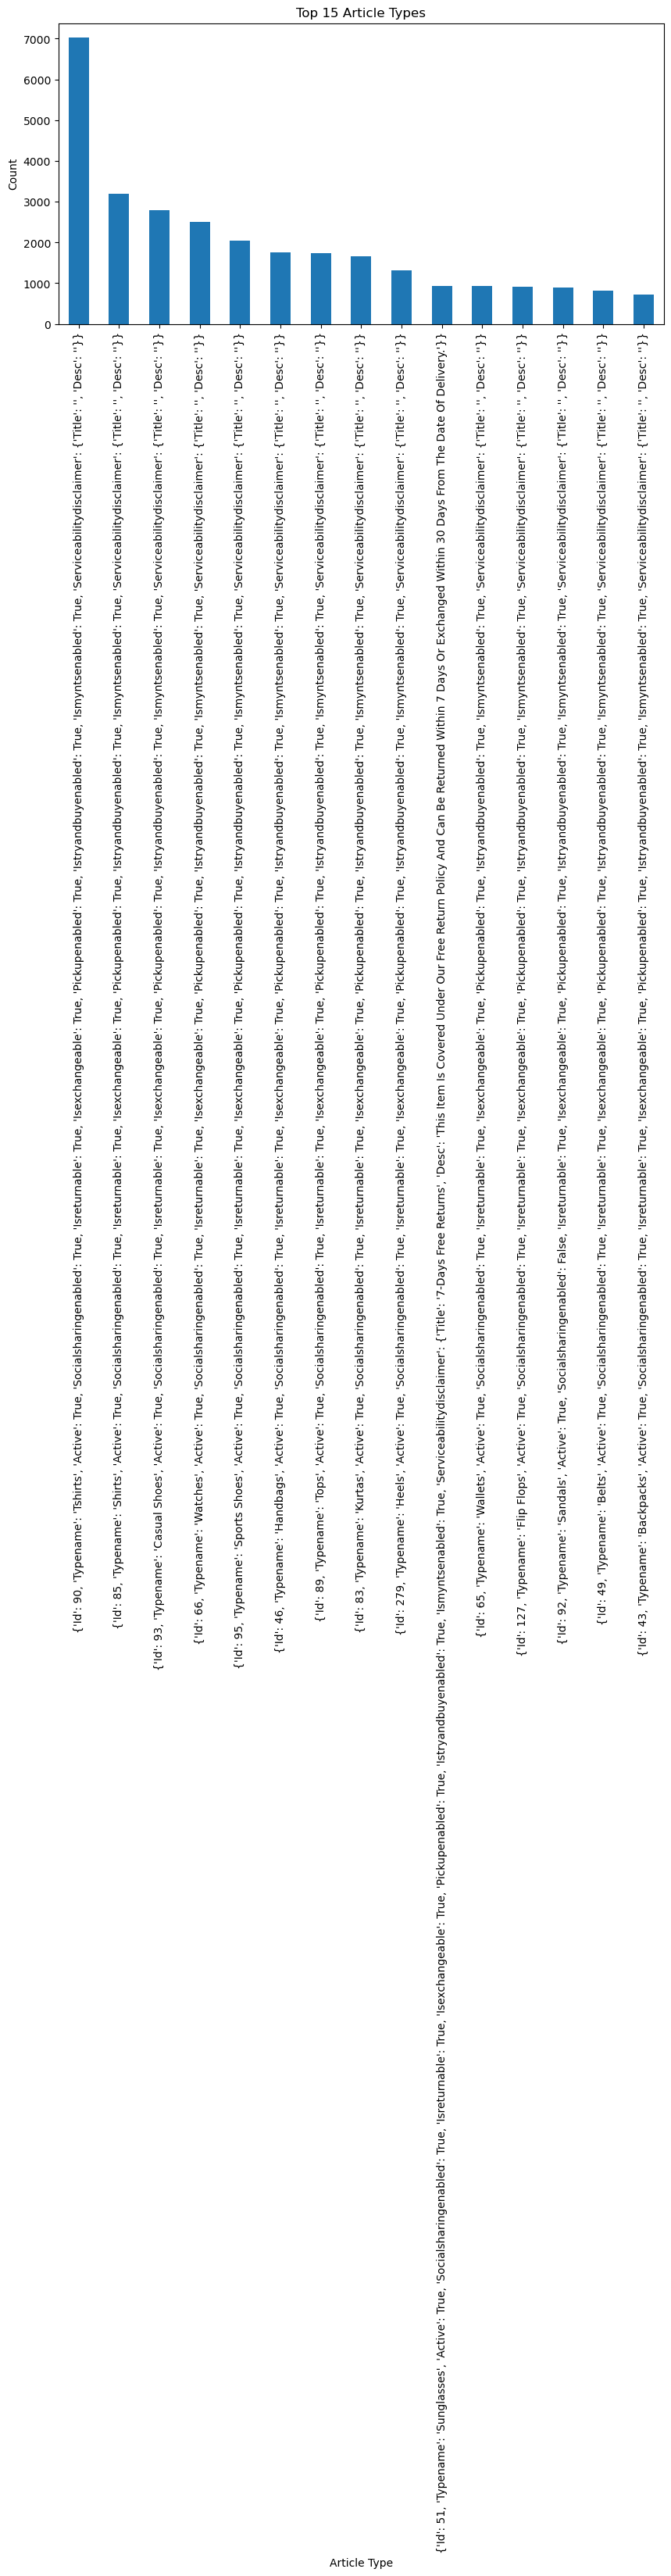

In [73]:
# Article Type Distribution - Are classes balanced?
plt.figure(figsize=(10,5))
df["articleType"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Article Types")
plt.xlabel("Article Type")
plt.ylabel("Count")
plt.show()


Insight-
What to observe
Some article types may have very few samples
Some may dominate heavily
📌 Decision impact
👉 Helps decide:
Which classes to keep
Which to drop during modeling

In [74]:
df["articleType"].value_counts().head(10)


articleType
{'Id': 90, 'Typename': 'Tshirts', 'Active': True, 'Socialsharingenabled': True, 'Isreturnable': True, 'Isexchangeable': True, 'Pickupenabled': True, 'Istryandbuyenabled': True, 'Ismyntsenabled': True, 'Serviceabilitydisclaimer': {'Title': '', 'Desc': ''}}                                                                                                                                                                    7029
{'Id': 85, 'Typename': 'Shirts', 'Active': True, 'Socialsharingenabled': True, 'Isreturnable': True, 'Isexchangeable': True, 'Pickupenabled': True, 'Istryandbuyenabled': True, 'Ismyntsenabled': True, 'Serviceabilitydisclaimer': {'Title': '', 'Desc': ''}}                                                                                                                                                                     3202
{'Id': 93, 'Typename': 'Casual Shoes', 'Active': True, 'Socialsharingenabled': True, 'Isreturnable': True, 'Isexchangeable': True, 'Pickupen

Insight-
Top values are very large
Then values drop quickly
👉 Long-tail behavior confirmed

3.CATEGORY SELECTION & IMAGE DATASET PREPARATION
(Bridge between EDA and Deep Learning)


We have:
A clean CSV
EDA insights
Thousands of products
But CNN models cannot learn everything at once.
So we must:
Focus on ONE gender
Ensure enough images per class
Create a folder-based image dataset


In [ ]:
# From EDA Result
TARGET_GENDER = "Men"


In [76]:


df = pd.read_csv("/Users/jein/env/env/Fashion_product_intelligence/data/fashion_products_clean.csv")

TARGET_GENDER = "Men"   

df_gender = df[df["gender"] == TARGET_GENDER]

print("Selected gender:", TARGET_GENDER)
print("Dataset shape:", df_gender.shape)

df_gender.head()


Selected gender: Men
Dataset shape: (22165, 13)


,id,productDisplayName,brandName,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,filename,imageURL
1,37297,Casio Enticer Men Black Analogue Watches (A504...,Casio,Men,"{'Id': 1, 'Typename': 'Accessories', 'Active':...","{'Id': 27, 'Typename': 'Watches', 'Active': Tr...","{'Id': 66, 'Typename': 'Watches', 'Active': Tr...",Black,Winter,2016,Casual,37297.jpg,http://assets.myntassets.com/v1/image/style/pr...
2,3721,Lee Men Black Canvas Belt,Lee,Men,"{'Id': 1, 'Typename': 'Accessories', 'Active':...","{'Id': 13, 'Typename': 'Belts', 'Active': True...","{'Id': 49, 'Typename': 'Belts', 'Active': True...",Black,Summer,2011,Casual,3721.jpg,http://assets.myntassets.com/v1/images/style/p...
4,2833,Lee Cooper Men's Casual Leather Darknight Blac...,Lee Cooper,Men,"{'Id': 10, 'Typename': 'Footwear', 'Active': T...","{'Id': 33, 'Typename': 'Shoes', 'Active': True...","{'Id': 93, 'Typename': 'Casual Shoes', 'Active...",Black,Summer,2012,Casual,2833.jpg,http://assets.myntassets.com/v1/images/style/p...
5,29289,Wrangler Men Miriam Checks Pink Shirt,Wrangler,Men,"{'Id': 9, 'Typename': 'Apparel', 'Active': Tru...","{'Id': 31, 'Typename': 'Topwear', 'Active': Tr...","{'Id': 85, 'Typename': 'Shirts', 'Active': Tru...",Pink,Summer,2012,Casual,29289.jpg,http://assets.myntassets.com/v1/images/style/p...
7,23684,Newhide Brown Men Antique Wallet,New Hide,Men,"{'Id': 1, 'Typename': 'Accessories', 'Active':...","{'Id': 26, 'Typename': 'Wallets', 'Active': Tr...","{'Id': 65, 'Typename': 'Wallets', 'Active': Tr...",Brown,Fall,2011,Casual,23684.jpg,http://assets.myntassets.com/v1/images/style/p...


In [77]:
# Save Filtered Dataset
df_gender.to_csv("model_dataset.csv", index=False)

